# 04 · Demand Forecasting with MLflow

**Pre-Hackathon Enablement · Notebook 4 of 6**

This is the deck's **Classical ML with MLflow** pattern (Demand / Freight
Forecasting). It needs only the synthetic **`orders`** data from **Notebook 1**.
The forecast it produces is written to a **Delta table** that **Notebook 5**
(Lakebase) loads and the **Notebook 6** app charts — so this model becomes a live
tile in the final app.

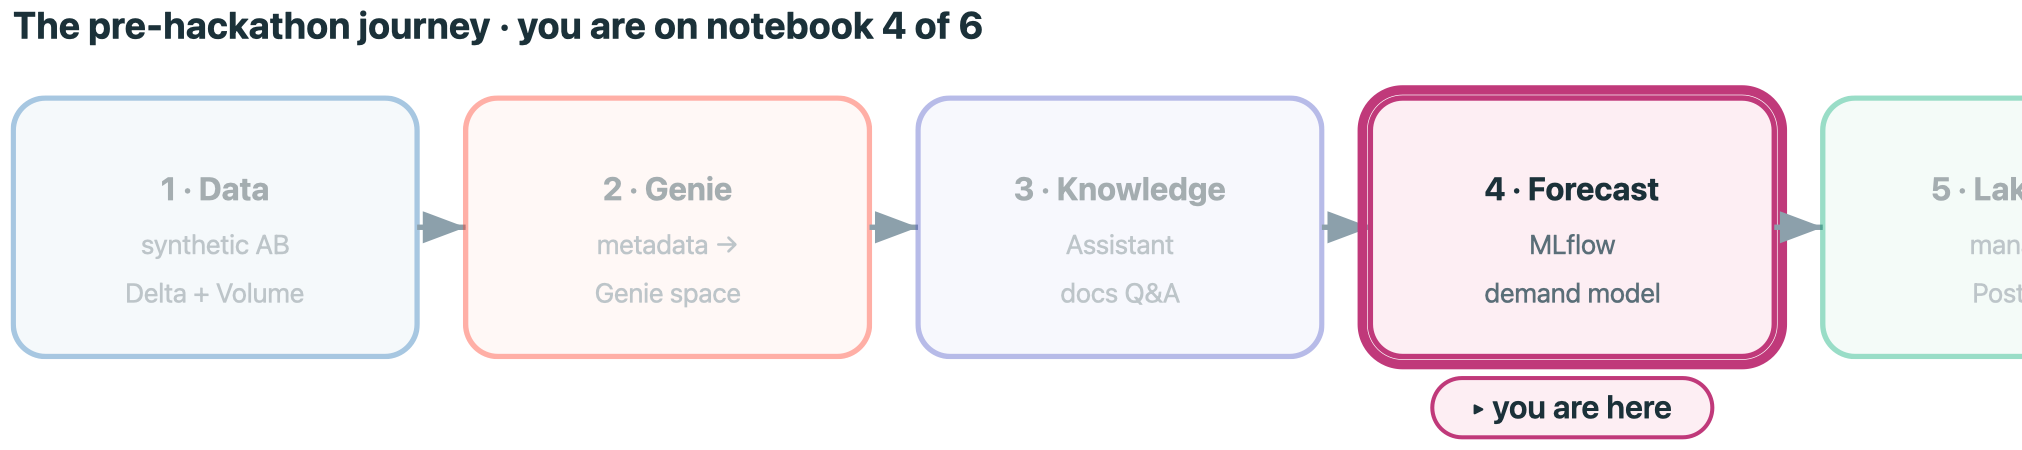

It also uses **Feature Engineering in Unity Catalog**: the engineered features
live in a governed **feature table**, and the model is trained + logged through
the Feature Engineering client, so feature **lineage** and **at-scoring feature
retrieval** are real — not hand-rolled.

> **This notebook is a runnable *scaffold*, a starting point** to be owned and
> extended. It forecasts monthly case demand by segment with a simple, honest
> baseline + model. Look for the **`# ⇒ OVER TO YOU`** markers for where to take it.

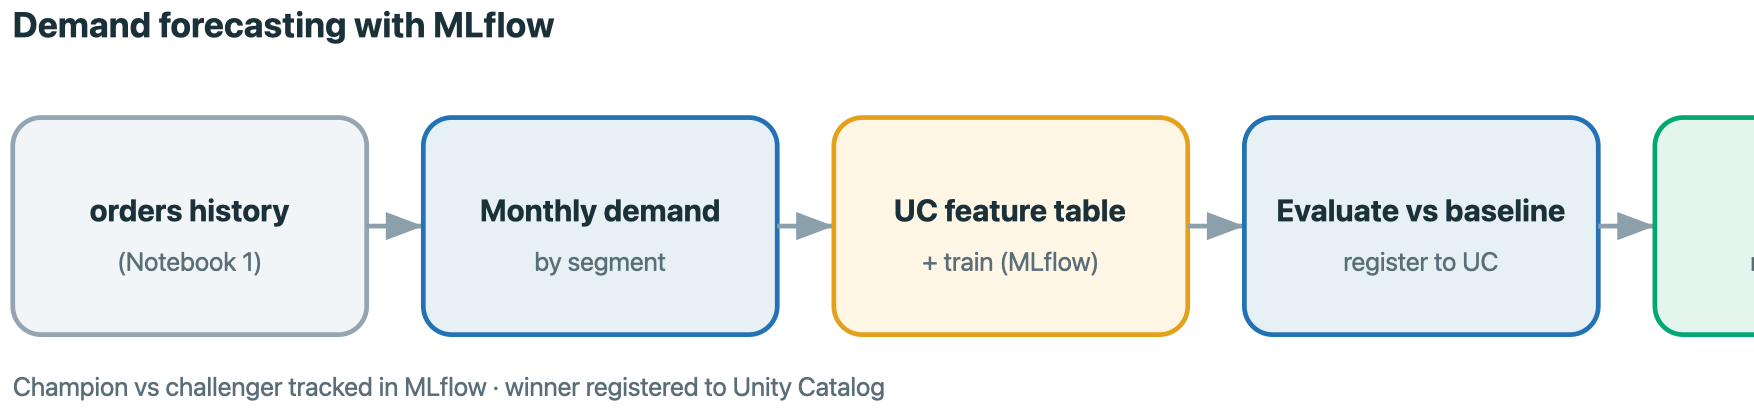

### What it does
1. Aggregate `orders` into a **monthly demand** series per segment
2. Engineer features and store them in a **UC feature table** (`demand_features`)
3. Build a **training set via `FeatureLookup`**, train a model, **track it in
   MLflow**, compare against a **baseline** (champion vs challenger), and
   **`fe.log_model`** it to Unity Catalog
4. **Score the holdout** — features looked up by key from the feature table
5. Produce a **forward forecast** and **write it to Delta** (Notebook 5 + the app read it)

> **Prerequisites:** Notebook 1 completed (the `orders` + `products` tables).
> Runs on **serverless** or a **Databricks Runtime for ML**. On an ML runtime the
> `databricks-feature-engineering` library is preinstalled; on serverless, Step 0
> installs it. Use the **same** `catalog`/`schema` you used in Notebook 1.

## Step 0 · Install the Feature Engineering client

On **serverless** compute (and plain runtimes) the Feature Engineering client
isn't preinstalled — install it, then restart Python so the import resolves. On a
**Databricks Runtime for ML** this is already present and the install is a no-op.

In [ ]:
%pip install --quiet databricks-feature-engineering
dbutils.library.restartPython()

## Step 1 · Parameters & the demand series

We forecast **monthly total cases by commercial segment** (5 segments). Using
segment keeps enough history per series; per-SKU forecasting is a natural
extension (see the end).

In [ ]:
# Create the widgets. Run this cell, set the values up top, then run the next cell.
dbutils.widgets.text("catalog", "technology_dev", "Unity Catalog catalog")
dbutils.widgets.text("schema", "abi_hackathon", "Schema base (username appended — matches NB1)")
dbutils.widgets.text("horizon", "3", "Forecast horizon (months)")
dbutils.widgets.text("test_months", "3", "Holdout months for evaluation")

In [ ]:
# Now read the widgets, derive the per-user names, and pull the monthly demand series.
import numpy as np
import pandas as pd
# Per-user identity (deterministic): _slug for schemas/db names, _dslug (hyphens)
# for app + serving-endpoint names, which don't allow underscores.
import re
CATALOG = dbutils.widgets.get("catalog").strip()
_user = spark.sql("SELECT current_user()").collect()[0][0]
_slug = re.sub(r"[^a-z0-9]+", "_", _user.split("@")[0].lower()).strip("_")[:30]
_dslug = _slug.replace("_", "-")
SCHEMA = f"{dbutils.widgets.get('schema').strip()}_{_slug}"
FQ = f"{CATALOG}.{SCHEMA}"
HORIZON = int(dbutils.widgets.get("horizon"))
TEST_MONTHS = int(dbutils.widgets.get("test_months"))

demand = spark.sql(f"""
    SELECT date_trunc('month', o.order_date) AS month,
           p.category AS segment,
           SUM(o.quantity_cases) AS cases
    FROM {FQ}.orders o
    JOIN {FQ}.products p ON o.product_sku = p.product_sku
    GROUP BY 1, 2
    ORDER BY 2, 1
""").toPandas()
demand["month"] = pd.to_datetime(demand["month"])
print(f"{demand['segment'].nunique()} segments · "
      f"{demand['month'].min():%Y-%m} → {demand['month'].max():%Y-%m} · {len(demand)} rows")
display(demand.head(12))

## Step 2 · Engineer features → a Unity Catalog feature table

Lag features (previous 1–3 months), a 3-month rolling mean, and calendar signals,
computed **within each segment** so they never leak across series. Instead of
keeping them in a local DataFrame, we persist them to a governed **feature table**
keyed by `(segment, month)` with the **Feature Engineering** client — reusable,
discoverable, and lineage-tracked.

In [ ]:
BASE_YEAR = int(demand["month"].dt.year.min())
NUM_FEATURES = ["lag_1", "lag_2", "lag_3", "roll_3", "month_num", "trend"]

def add_features(df):
    df = df.sort_values(["segment", "month"]).copy()
    for L in (1, 2, 3):
        df[f"lag_{L}"] = df.groupby("segment")["cases"].shift(L)
    df["roll_3"] = (df.groupby("segment")["cases"]
                      .transform(lambda s: s.shift(1).rolling(3).mean()))
    df["month_num"] = df["month"].dt.month
    df["trend"] = (df["month"].dt.year - BASE_YEAR) * 12 + df["month"].dt.month
    return df

feat = add_features(demand).dropna().reset_index(drop=True)
print(f"{len(feat)} feature rows · keys=(segment, month) · {len(NUM_FEATURES)} features")

In [ ]:
from databricks.feature_engineering import FeatureEngineeringClient, FeatureLookup

fe = FeatureEngineeringClient()
FEATURE_TABLE = f"{FQ}.demand_features"

features_sdf = spark.createDataFrame(feat[["segment", "month"] + NUM_FEATURES])

# Idempotent: create the table on first run, upsert (merge) on re-runs.
try:
    fe.create_table(
        name=FEATURE_TABLE,
        primary_keys=["segment", "month"],
        df=features_sdf,
        description="Monthly demand features per segment: lags, 3-mo rolling mean, calendar, trend.",
    )
    print(f"Created feature table {FEATURE_TABLE} ({features_sdf.count()} rows).")
except Exception as e:
    fe.write_table(name=FEATURE_TABLE, df=features_sdf, mode="merge")
    print(f"Feature table already existed — merged latest features ({type(e).__name__}).")

## Step 3 · Train from a `FeatureLookup` training set, log with the FE client

We build the training set by **looking features up from the table by key** — this
is what records **lineage**. Then we train a scikit-learn **Pipeline** (one-hot the
segment + gradient boosting), log a **baseline** (persistence: next month = last
month) and the model, compare them (champion vs challenger), and register the
winner with `fe.log_model` — so scoring can **auto-join** features.

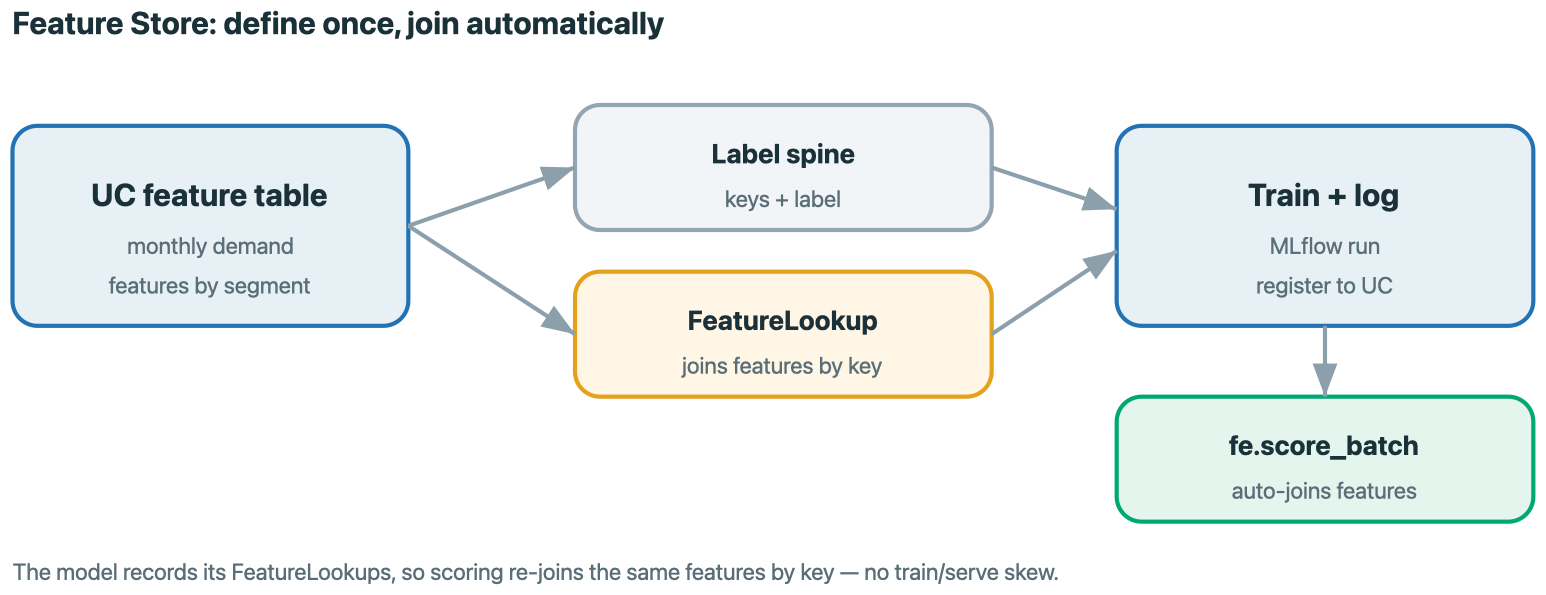

The key idea: the model **remembers the `FeatureLookup`s** it was trained on. At
scoring time (Step 4) you pass only the keys and the **exact same features are
re-joined** from the table by key — so training and serving can't drift apart.

In [ ]:
import mlflow
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor

mlflow.set_registry_uri("databricks-uc")
# Pin an explicit MLflow experiment. On serverless, auto-resolving the *notebook*
# experiment can fail ("Could not find experiment with ID None" / the extraContext
# call isn't py4j-whitelisted), so point at a per-user experiment (created if new).
mlflow.set_experiment(f"/Users/{spark.sql('SELECT current_user()').collect()[0][0]}/abi_demand_forecast")
MODEL_NAME = f"{CATALOG}.{SCHEMA}.demand_forecaster"

# Label spine (keys + label); features come from the table via FeatureLookup.
label_sdf = spark.createDataFrame(feat[["segment", "month", "cases"]])
training_set = fe.create_training_set(
    df=label_sdf,
    feature_lookups=[FeatureLookup(table_name=FEATURE_TABLE,
                                   lookup_key=["segment", "month"],
                                   feature_names=NUM_FEATURES)],
    label="cases",
)
tdf = training_set.load_df().toPandas()
tdf["month"] = pd.to_datetime(tdf["month"])

# Time-based split (hold out the last few months).
cutoff = tdf["month"].max() - pd.DateOffset(months=TEST_MONTHS)
train, test = tdf[tdf["month"] <= cutoff], tdf[tdf["month"] > cutoff]
MODEL_INPUT = ["segment"] + NUM_FEATURES          # segment is encoded inside the pipeline
X_train, y_train = train[MODEL_INPUT], train["cases"]
X_test,  y_test  = test[MODEL_INPUT],  test["cases"]
print(f"train={len(train)} · test={len(test)} rows (last {TEST_MONTHS} months)")

def mae(y, p):  return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(p, float))))
def mape(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float); m = y != 0
    return float(np.mean(np.abs((y[m] - p[m]) / y[m])) * 100)

In [ ]:
model = Pipeline([
    ("prep", ColumnTransformer(
        [("seg", OneHotEncoder(handle_unknown="ignore"), ["segment"])],
        remainder="passthrough")),
    ("gbr", GradientBoostingRegressor(random_state=42)),
])

# Baseline: persistence (next month = previous month = lag_1).
base_mae, base_mape = mae(y_test, test["lag_1"]), mape(y_test, test["lag_1"])

with mlflow.start_run(run_name="demand_gbr") as run:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    model_mae, model_mape = mae(y_test, pred), mape(y_test, pred)

    mlflow.log_params({"model": "GBR+OneHot", "test_months": TEST_MONTHS,
                       "n_features": len(NUM_FEATURES)})
    mlflow.log_metrics({"baseline_mae": base_mae, "baseline_mape": base_mape,
                        "model_mae": model_mae, "model_mape": model_mape})
    fe.log_model(                       # packages the FeatureLookup metadata with the model
        model=model,
        artifact_path="demand_model",
        flavor=mlflow.sklearn,
        training_set=training_set,      # records feature lineage
        registered_model_name=MODEL_NAME,
    )
    run_id = run.info.run_id

print(f"Baseline  MAE={base_mae:,.0f}  MAPE={base_mape:.1f}%")
print(f"Model     MAE={model_mae:,.0f}  MAPE={model_mape:.1f}%")
champion = "model" if model_mae < base_mae else "baseline"
print(f"🏆 Champion: {champion} · registered {MODEL_NAME} · run {run_id}")

## Step 4 · Score the holdout (features looked up by key)

The payoff of the feature table: at scoring time you pass only the **keys**
`(segment, month)` and the features are **joined for you** from `demand_features` —
no feature code at inference.

> **`fe.score_batch` vs. serverless.** The one-liner `fe.score_batch(model_uri, df)`
> is the production **batch-scoring** path — it runs the model as a **Spark UDF** and
> auto-joins the features. But that Spark-UDF backend can **invalidate a serverless
> Spark Connect session** (*"session is no longer usable"*), which kills the rest of
> the notebook. So on **serverless** we get the identical result the safe way: look
> the features up with the FE client (the same call as Step 3) and predict with the
> in-memory model. On a **classic ML cluster** you can call `fe.score_batch` directly:
> ```python
> scored = fe.score_batch(model_uri=f"runs:/{run_id}/demand_model",
>                         df=spark.createDataFrame(test[["segment", "month"]])).toPandas()
> ```

In [ ]:
from databricks.feature_engineering import FeatureLookup

# Serverless-safe scoring: look the features up by key from the governed table
# (same mechanism as Step 3's training set — no Spark UDF), then predict locally.
# This still proves the features come from `demand_features`, joined by (segment, month).
scored = fe.create_training_set(
    df=spark.createDataFrame(test[["segment", "month", "cases"]]),
    feature_lookups=[FeatureLookup(table_name=FEATURE_TABLE,
                                   lookup_key=["segment", "month"], feature_names=NUM_FEATURES)],
    label="cases",
).load_df().toPandas()
scored["prediction"] = model.predict(scored[MODEL_INPUT])

# Sanity: the feature-lookup scoring reproduces Step 3's in-memory evaluation.
print(f"Feature-lookup scoring MAE = {mae(scored['cases'], scored['prediction']):,.0f}  "
      f"(≈ Step 3 model MAE {model_mae:,.0f})")
display(scored.sort_values(["month", "segment"])[["segment", "month", "cases", "prediction"]].head(12))

## Step 5 · Forward forecast

Recursively roll the model forward `HORIZON` months per segment, feeding each
prediction back in as the next month's lag. These **future** months don't exist
in the feature table yet, so we build their features in-memory and call the
trained pipeline directly — feature-store *lookup* is for keys that already
exist, while recursive multi-step forecasting synthesizes the next row each step.

In [ ]:
def forecast_segment(seg, horizon):
    hist = demand[demand["segment"] == seg].sort_values("month")
    cases = hist["cases"].tolist()
    last_month = hist["month"].max()
    out = []
    for h in range(1, horizon + 1):
        m = last_month + pd.DateOffset(months=h)
        row = {"segment": seg, "lag_1": cases[-1], "lag_2": cases[-2],
               "lag_3": cases[-3], "roll_3": float(np.mean(cases[-3:])),
               "month_num": m.month, "trend": (m.year - BASE_YEAR) * 12 + m.month}
        yhat = float(model.predict(pd.DataFrame([row])[MODEL_INPUT])[0])
        out.append({"segment": seg, "month": m.date(), "forecast_cases": max(0, round(yhat))})
        # Feed the prediction back in so it becomes lag_1 for the next month —
        # this is what makes the roll-forward multi-step (recursive forecasting).
        cases.append(yhat)
    return out

rows = [r for seg in demand["segment"].unique() for r in forecast_segment(seg, HORIZON)]
forecast = pd.DataFrame(rows)
display(forecast.sort_values(["month", "segment"]))

In [ ]:
# Persist the forecast to Delta. Notebook 5 (Lakebase) copies this into Postgres
# and the Notebook 6 app charts it — so this write is what makes the model show up
# in the app. Columns: segment, month (date), forecast_cases.
(spark.createDataFrame(forecast)
      .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
      .saveAsTable(f"{FQ}.demand_forecast"))
print(f"Wrote {FQ}.demand_forecast ({len(forecast)} rows) — Notebook 5 loads it into Lakebase.")

## Step 6 · Register a serving copy + create a Model Serving endpoint

The Notebook 6 app does **live what-if inference** — a user types recent volumes
and sees a prediction instantly. That calls a **Model Serving endpoint**, not
`fe.score_batch`. Because the app runs on serverless with **no Spark** (so no
feature-store *lookup*), we register a **plain-sklearn copy** of the same pipeline
whose inputs are the feature *values* themselves, then stand it up behind a
**scale-to-zero** endpoint. The `fe.log_model` model above stays the governed
batch/lineage model; this copy is purely for interactive serving.

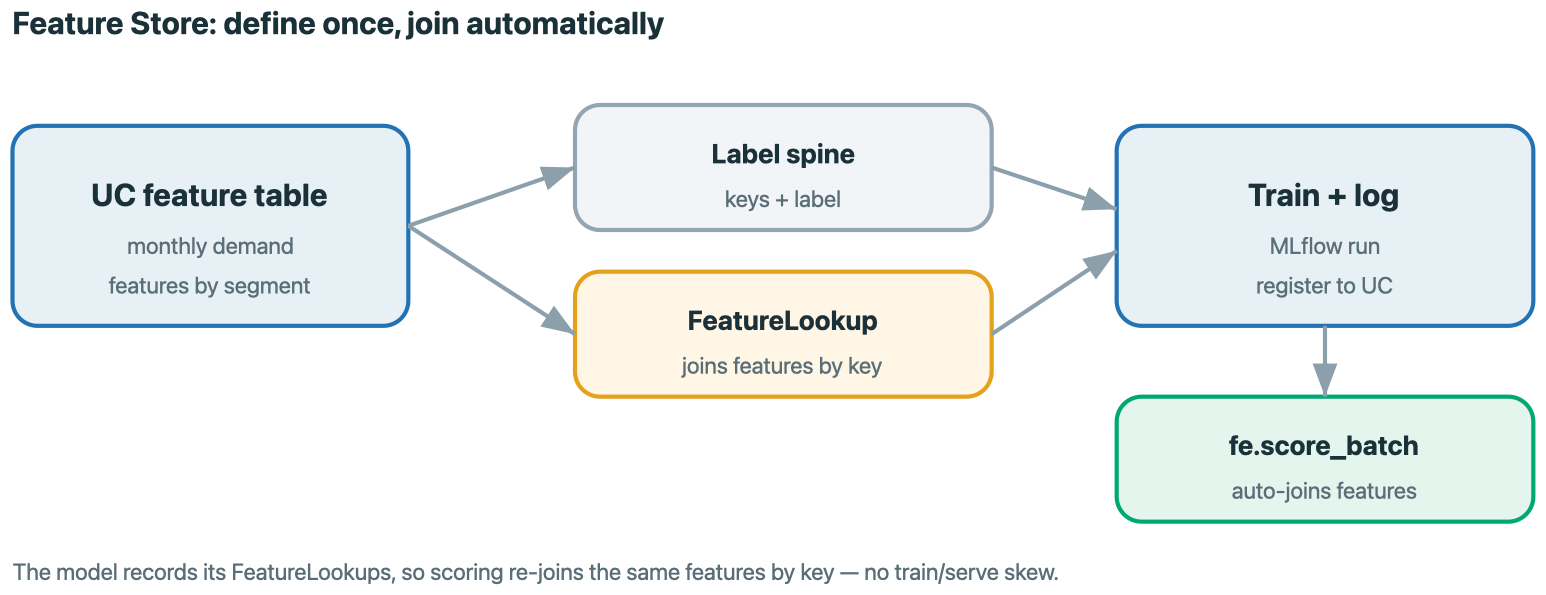

In [ ]:
# A plain-sklearn copy (no FeatureLookup): its inputs ARE the 7 feature columns,
# so the app can pass typed features directly. Same algorithm + data as Step 3.
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

SERVING_MODEL = f"{FQ}.demand_forecaster_serving"
FORECAST_ENDPOINT = f"abi-demand-forecast-{_dslug}"   # per-user (no collisions in a shared workspace)

serving_pipe = Pipeline([
    ("prep", ColumnTransformer(
        [("seg", OneHotEncoder(handle_unknown="ignore"), ["segment"])], remainder="passthrough")),
    ("gbr", GradientBoostingRegressor(random_state=42)),
])
serving_pipe.fit(feat[MODEL_INPUT], feat["cases"])
sig = infer_signature(feat[MODEL_INPUT], serving_pipe.predict(feat[MODEL_INPUT]))

mlflow.set_registry_uri("databricks-uc")
mlflow.set_experiment(f"/Users/{spark.sql('SELECT current_user()').collect()[0][0]}/abi_demand_forecast")
with mlflow.start_run(run_name="demand_gbr_serving"):
    mlflow.sklearn.log_model(
        sk_model=serving_pipe, artifact_path="model", signature=sig,
        input_example=feat[MODEL_INPUT].head(3), registered_model_name=SERVING_MODEL)

SERVING_VERSION = str(max(int(v.version) for v in
    MlflowClient(registry_uri="databricks-uc").search_model_versions(f"name='{SERVING_MODEL}'")))
print(f"Registered {SERVING_MODEL} v{SERVING_VERSION}")
print(f"⇒ In app.yaml (Notebook 6) set: FORECAST_ENDPOINT = {FORECAST_ENDPOINT}")
print(f"⇒ In app.yaml set: FORECAST_BASE_YEAR = {BASE_YEAR}  (matches the model's `trend` feature).")

In [ ]:
# Create (or update) the endpoint — scale-to-zero keeps cost ~$0 when idle.
from databricks.sdk import WorkspaceClient
from databricks.sdk.service.serving import EndpointCoreConfigInput, ServedEntityInput

w = WorkspaceClient()
served = [ServedEntityInput(name="demand-forecaster-serving", entity_name=SERVING_MODEL,
                            entity_version=SERVING_VERSION, scale_to_zero_enabled=True,
                            workload_size="Small")]
if FORECAST_ENDPOINT in [e.name for e in w.serving_endpoints.list()]:
    w.serving_endpoints.update_config(name=FORECAST_ENDPOINT, served_entities=served)
    print(f"Updating endpoint '{FORECAST_ENDPOINT}' → v{SERVING_VERSION} (provisioning ~10 min).")
else:
    w.serving_endpoints.create(
        name=FORECAST_ENDPOINT,
        # EndpointCoreConfigInput requires `name` in the SDK version on ML/serverless
        # runtimes — set it to the endpoint name to match the outer `name=` argument.
        config=EndpointCoreConfigInput(name=FORECAST_ENDPOINT, served_entities=served))
    print(f"Creating endpoint '{FORECAST_ENDPOINT}' (first build ~10-15 min).")

## ✅ Recap & `# ⇒ OVER TO YOU`

A working, MLflow-tracked demand forecast — with features in a **Unity Catalog
feature table**, trained through a `FeatureLookup` training set and logged with
`fe.log_model` (so lineage + at-scoring feature retrieval are real), and
registered to Unity Catalog. It's intentionally simple — here's where to take it:

- **Granularity:** forecast **per SKU** or **per region**, not just segment.
- **Models:** try Prophet / SARIMAX / AutoML; add more challengers to the
  baseline-vs-model comparison.
- **Features:** add promotions, price, holidays to `demand_features` — the feature
  table makes them reusable across models and teams.
- **Point-in-time:** for leak-free training on event data, use a **timeseries
  feature table** with point-in-time lookups.
- **Validation:** proper **backtesting** (rolling-origin) instead of a single holdout.
- **Serving:** Step 6 stands up a **Model Serving** endpoint (`abi-demand-forecast`)
  for the app's live what-if inference; you can also batch-score on a schedule with
  `fe.score_batch`. Note the `FORECAST_BASE_YEAR` printed above for Notebook 6.
- **Ops:** tune hyperparameters, add a UC model **alias** (champion), monitor drift.

**Next → Notebook 5:** stand up **Lakebase** (managed Postgres) for the app's
transactional state — and load this `demand_forecast` table so the app can chart it.